# Series - Vias de Ingreso 
Se construye una serie mensual para cada vía de ingreso:
- Aérea
- Terrestre
- Marítima

En total se obtendrán tres series.


## Librerías y Config

In [9]:
from pathlib import Path
import warnings
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    ExponentialSmoothing
)

from sklearn.metrics import mean_absolute_error, mean_squared_error


pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "figure.figsize": (13, 5),
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11
})

## Carga y análisis de datos

In [11]:
RUTA_DATOS = Path("../data/raw/Base_Migracion_2009-2026jun.xlsx")



if not RUTA_DATOS.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo en: {RUTA_DATOS.resolve()}"
    )

archivo_excel = pd.ExcelFile(RUTA_DATOS)

print("Hojas disponibles:")
print(archivo_excel.sheet_names)
datos_raw = pd.read_excel(
    RUTA_DATOS,
    sheet_name="Datos"
)

notas = pd.read_excel(
    RUTA_DATOS,
    sheet_name="Notas"
)

print("Dimensiones de la hoja Datos:", datos_raw.shape)
print("Dimensiones de la hoja Notas:", notas.shape)

display(datos_raw.head())
datos_raw.info()

display(
    pd.DataFrame({
        "Columnas": datos_raw.columns,
        "Tipos de datos": datos_raw.dtypes,
        "Valores nulos": datos_raw.isnull().sum()
    })
)

Hojas disponibles:
['Datos', 'Notas']
Dimensiones de la hoja Datos: (161036, 13)
Dimensiones de la hoja Notas: (9, 2)


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.00
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.00
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.00
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.00
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.00


<class 'pandas.DataFrame'>
RangeIndex: 161036 entries, 0 to 161035
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Año                    161036 non-null  int64  
 1   Mes cod                161036 non-null  int64  
 2   Mes                    161036 non-null  str    
 3   Vía                    161036 non-null  str    
 4   Frontera               161036 non-null  str    
 5   País                   161036 non-null  str    
 6   Región                 161036 non-null  str    
 7   Región dos             161036 non-null  str    
 8   Regiones OMT           161036 non-null  str    
 9   MCEO                   161036 non-null  str    
 10  Agrupación Residencia  161036 non-null  str    
 11  Tipo de Viajero        161036 non-null  str    
 12  Viajero                161036 non-null  float64
dtypes: float64(1), int64(2), str(10)
memory usage: 16.0 MB


,Columnas,Tipos de datos,Valores nulos
Año,Año,int64,0
Mes cod,Mes cod,int64,0
Mes,Mes,str,0
Vía,Vía,str,0
Frontera,Frontera,str,0
País,País,str,0
Región,Región,str,0
Región dos,Región dos,str,0
Regiones OMT,Regiones OMT,str,0
MCEO,MCEO,str,0


## Limpieza y preparación de datos

In [17]:
# limpieza y prepara los datos
datos = datos_raw.copy()
datos.columns = (datos.columns.astype(str).str.strip())

# validar columnas necesarias
columnas_necesarias = [
    "Año",
    "Mes cod",
    "Mes",
    "Vía",
    "Tipo de Viajero",
    "Viajero"
]

columnas_faltantes = [
    columna 
    for columna in columnas_necesarias
    if columna not in datos.columns
]
if columnas_faltantes:
    raise ValueError(
        f"Faltan columnas necesarias en los datos: {columnas_faltantes}"
    )
print("Columnas necesarias presentes en los datos.")

# Convertir variables 
datos["Año"] = pd.to_numeric(datos["Año"], errors="coerce")
datos["Mes cod"] = pd.to_numeric(datos["Mes cod"], errors="coerce")
datos["Viajero"] = pd.to_numeric(datos["Viajero"], errors="coerce")

#Limpiar 
columnas_texto = [
    "Mes",
    "Vía",
    "Tipo de Viajero"
]

for columna in columnas_texto:
    datos[columna] = (
        datos[columna]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

# estandarizar categorias
datos["Vía"] = datos["Vía"].str.title()
datos["Tipo de Viajero"] = datos["Tipo de Viajero"].str.title()

datos["Vía"] = datos["Vía"].replace({
    "Aerea": "Aérea",
    "Maritima": "Marítima"
})

# crear fecha mensual 
anio_texto = datos["Año"].astype("Int64").astype(str)
mes_texto = datos["Mes cod"].astype("Int64").astype(str).str.zfill(2)

datos["Fecha"] = pd.to_datetime(
    anio_texto + "-" + mes_texto + "-01",
    errors="coerce"
)

# revisar resultado 
display(
    datos[
        [
            "Año",
            "Mes cod",
            "Mes",
            "Fecha",
            "Vía",
            "Tipo de Viajero",
            "Viajero"
        ]
    ].head()
)

# valores faltantes 
faltantes = (
    datos.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Cantidad_faltantes")
)

faltantes["Porcentaje"] = (
    faltantes["Cantidad_faltantes"]
    / len(datos)
    * 100
)

display(faltantes)

#fehcas invalidas 
fechas_invalidas = datos["Fecha"].isna().sum()

print("Fechas inválidas:", fechas_invalidas)

#duplicados 
cantidad_duplicados = datos.duplicated().sum()

print("Duplicados exactos:", cantidad_duplicados)

if cantidad_duplicados > 0:
    display(
        datos[
            datos.duplicated(keep=False)
        ].sort_values("Fecha").head(20)
    )

#negativos 
cantidad_negativos = (datos["Viajero"] < 0).sum()
cantidad_ceros = (datos["Viajero"] == 0).sum()

print("Valores negativos:", cantidad_negativos)
print("Valores iguales a cero:", cantidad_ceros)

# atipicos 
q1 = datos["Viajero"].quantile(0.25)
q3 = datos["Viajero"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

atipicos = datos[
    (datos["Viajero"] < limite_inferior)
    | (datos["Viajero"] > limite_superior)
]

print("Cantidad de valores atípicos según IQR:", len(atipicos))


Columnas necesarias presentes en los datos.


,Año,Mes cod,Mes,Fecha,Vía,Tipo de Viajero,Viajero
0,2009,1,Ene,2009-01-01,Aérea,Turista,1.00
1,2009,1,Ene,2009-01-01,Aérea,Turista,716.00
2,2009,1,Ene,2009-01-01,Aérea,Turista,4.00
3,2009,1,Ene,2009-01-01,Aérea,Turista,5.00
4,2009,1,Ene,2009-01-01,Aérea,Turista,1.00


,Cantidad_faltantes,Porcentaje
Año,0,0.00
Mes cod,0,0.00
Mes,0,0.00
Vía,0,0.00
Frontera,0,0.00
País,0,0.00
Región,0,0.00
Región dos,0,0.00
Regiones OMT,0,0.00
MCEO,0,0.00


Fechas inválidas: 0
Duplicados exactos: 0
Valores negativos: 0
Valores iguales a cero: 54
Cantidad de valores atípicos según IQR: 26390


In [19]:
# filtro de variables comparables 
TIPOS_COMPARABLES = [
    "Turista",
    "Excursionista"
]

VIAS = [
    "Aérea",
    "Terrestre",
    "Marítima"
]

datos_vias = datos[
    datos["Tipo de Viajero"].isin(TIPOS_COMPARABLES)
    & datos["Vía"].isin(VIAS)
    & datos["Fecha"].notna()
    & datos["Viajero"].notna()
].copy()

print("Tipos de viajero incluidos:")
display(datos_vias["Tipo de Viajero"].value_counts())

print("Vías incluidas:")
display(datos_vias["Vía"].value_counts())

print("Registros originales:", len(datos))
print("Registros utilizados:", len(datos_vias))
print("Registros excluidos:", len(datos) - len(datos_vias))

Tipos de viajero incluidos:


Tipo de Viajero
Turista          117912
Excursionista     19730
Name: count, dtype: Int64

Vías incluidas:


Vía
Terrestre    105111
Aérea         24508
Marítima       8023
Name: count, dtype: Int64

Registros originales: 161036
Registros utilizados: 137642
Registros excluidos: 23394


## Construcción de las series mensuales 

In [25]:
# se construyen las series mensuales
# sumar viajeros por fecha y via 
viajeros_mensuales = (
    datos_vias
    .groupby(
        ["Fecha", "Vía"],
        as_index=False
    )["Viajero"]
    .sum()
)
display(viajeros_mensuales.head(10))

#convertir a tabla de series
series_vias = (
    viajeros_mensuales
    .pivot(
        index="Fecha",
        columns="Vía",
        values="Viajero"
    )
    .sort_index()
)
series_vias = series_vias.reindex(
    columns=VIAS
)

calendario_completo = pd.date_range(
    start=series_vias.index.min(),
    end=series_vias.index.max(),
    freq="MS"
)

series_vias = series_vias.reindex(
    calendario_completo
)

series_vias.index.name = "Fecha"

# meses sin registro 
faltantes_por_via = (
    series_vias
    .isna()
    .sum()
    .to_frame("Meses_sin_registro")
)

display(faltantes_por_via)

series_vias = series_vias.fillna(0)
display(series_vias.head())


# RESUMEN 
def resumen_serie(serie: pd.Series, nombre: str) -> dict:
    return {
        "Serie": nombre,
        "Inicio": serie.index.min(),
        "Fin": serie.index.max(),
        "Frecuencia": pd.infer_freq(serie.index),
        "Observaciones": len(serie),
        "Meses_con_cero": int((serie == 0).sum()),
        "Total_acumulado": serie.sum(),
        "Media_mensual": serie.mean(),
        "Mediana": serie.median(),
        "Desviación_estándar": serie.std(),
        "Mínimo": serie.min(),
        "Máximo": serie.max()
    }

resumen_series = pd.DataFrame([
    resumen_serie(
        series_vias[via],
        via
    )
    for via in VIAS
])

display(resumen_series)

,Fecha,Vía,Viajero
0,2009-01-01,Aérea,"81,693.00"
1,2009-01-01,Marítima,809.00
2,2009-01-01,Terrestre,"67,442.03"
3,2009-02-01,Aérea,"70,099.00"
4,2009-02-01,Marítima,938.00
5,2009-02-01,Terrestre,"56,266.69"
6,2009-03-01,Aérea,"84,494.00"
7,2009-03-01,Marítima,"1,190.00"
8,2009-03-01,Terrestre,"73,111.67"
9,2009-04-01,Aérea,"80,618.00"


,Meses_sin_registro
Vía,
Aérea,0
Terrestre,0
Marítima,114


Vía,Aérea,Terrestre,Marítima
Fecha,,,
2009-01-01,"81,693.00","67,442.03",809.00
2009-02-01,"70,099.00","56,266.69",938.00
2009-03-01,"84,494.00","73,111.67","1,190.00"
2009-04-01,"80,618.00","89,897.47","1,498.00"
2009-05-01,"64,621.00","58,898.52","1,040.00"


,Serie,Inicio,Fin,Frecuencia,Observaciones,Meses_con_cero,Total_acumulado,Media_mensual,Mediana,Desviación_estándar,Mínimo,Máximo
0,Aérea,2009-01-01,2026-06-01,MS,210,0,"19,019,418.55","90,568.66","90,941.00","27,855.30",489.00,"158,463.00"
1,Terrestre,2009-01-01,2026-06-01,MS,210,0,"27,592,253.33","131,391.68","134,582.88","60,815.99","5,240.00","291,272.07"
2,Marítima,2009-01-01,2026-06-01,MS,210,114,"100,241.00",477.34,0.00,541.26,0.00,"1,650.00"


---

podemos notar que existe la misma cantidad de observaciones por cada via de ingreso, sin embargo Maritima contiene meses con cero de 114 lo que se nota por sus totales acumulares y su media mensual. 
Esto nos ayuda a previsualizar losd atos antes de realizar un análisis más profundo.

## Análisis exploratorio de las vías 

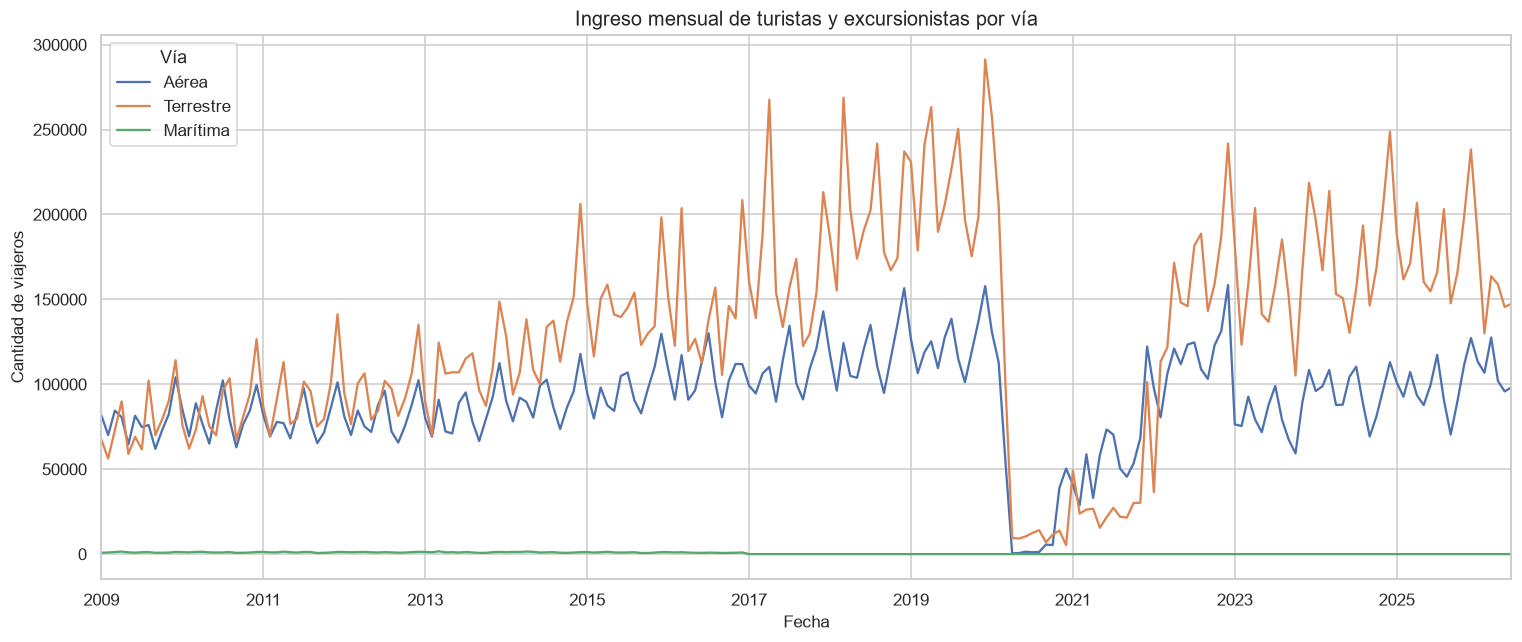

In [26]:
# analizando grafico conjunto
ax = series_vias.plot(
    figsize=(14, 6),
    linewidth=1.5
)

ax.set_title(
    "Ingreso mensual de turistas y excursionistas por vía"
)

ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de viajeros")
ax.legend(title="Vía")

plt.tight_layout()
plt.show()

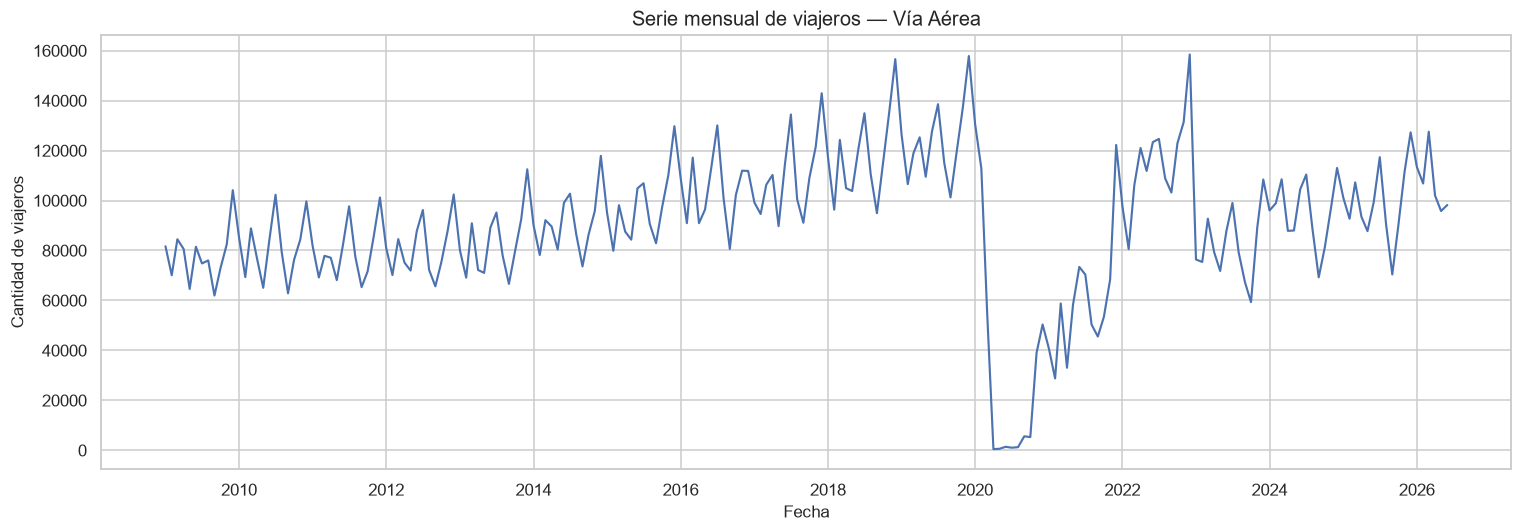

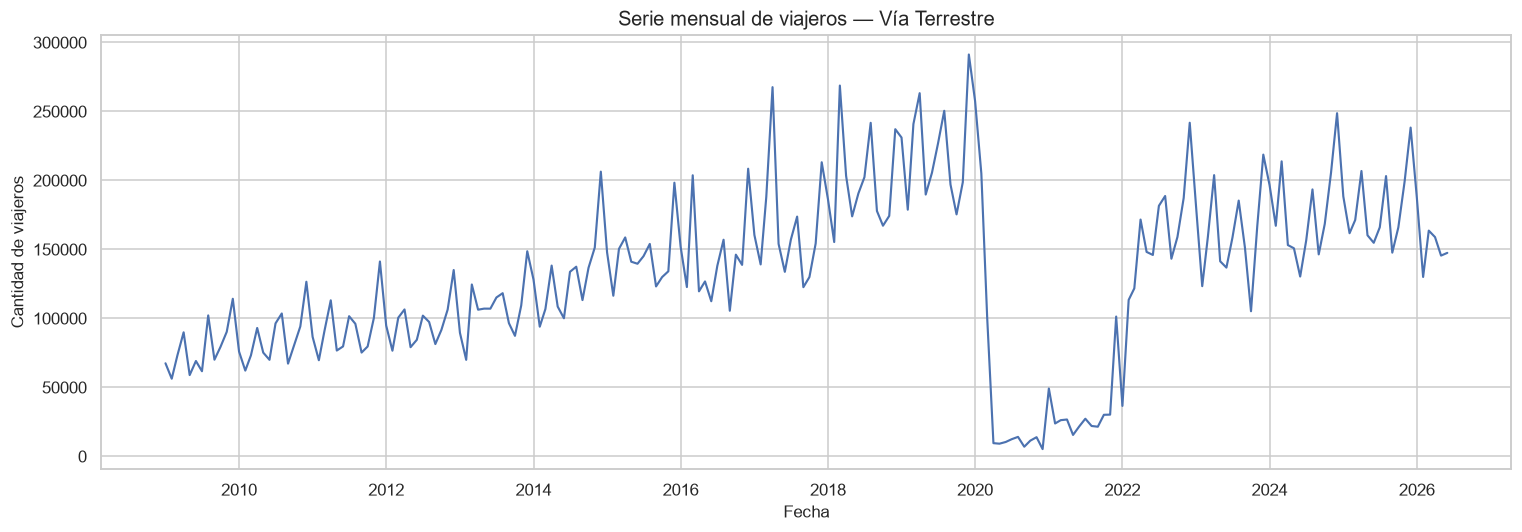

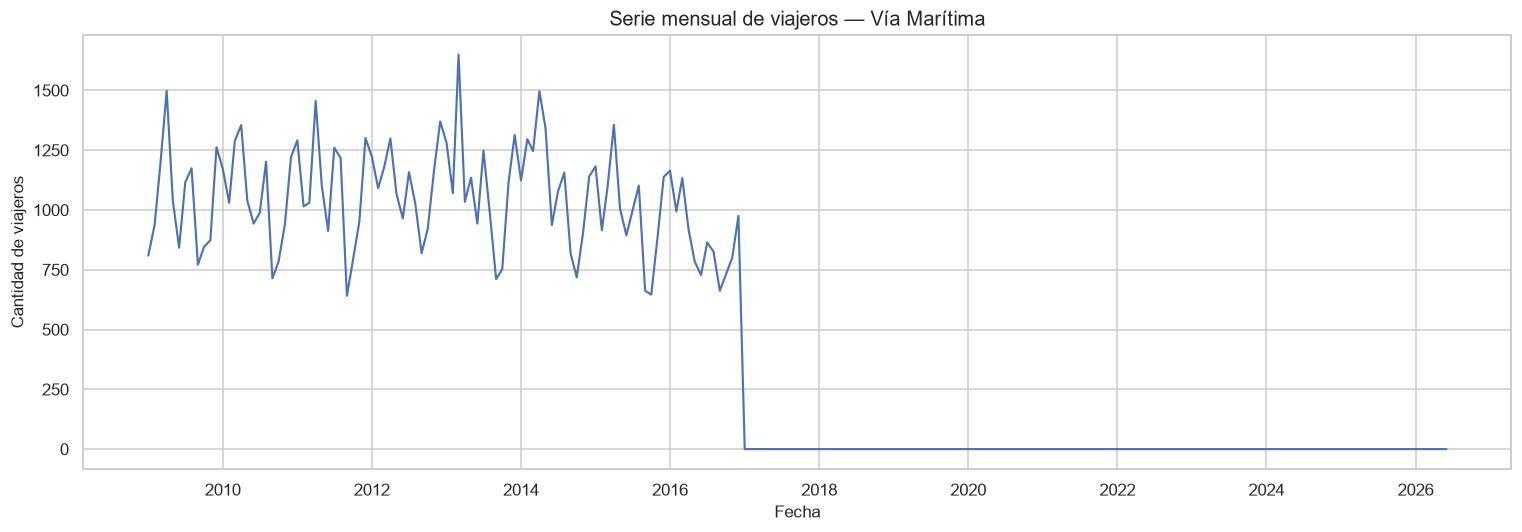

In [27]:
# grafico por cada via
for via in VIAS:
    plt.figure(figsize=(14, 5))

    plt.plot(
        series_vias.index,
        series_vias[via],
        linewidth=1.4
    )

    plt.title(
        f"Serie mensual de viajeros — Vía {via}"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Cantidad de viajeros")

    plt.tight_layout()
    plt.show()

Vía,Aérea,Terrestre,Marítima
Fecha,,,
2009,"935,379.00","932,445.85","12,358.00"
2010,"974,233.00","1,017,876.00","12,675.00"
2011,"955,964.00","1,110,781.60","12,969.00"
2012,"970,530.00","1,155,729.48","13,282.00"
2013,"996,787.00","1,279,673.75","13,242.00"
2014,"1,092,353.00","1,554,568.32","13,256.00"
2015,"1,167,412.00","1,738,593.04","11,881.00"
2016,"1,255,323.43","1,731,125.32","10,578.00"
2017,"1,313,790.00","1,993,861.29",0.00


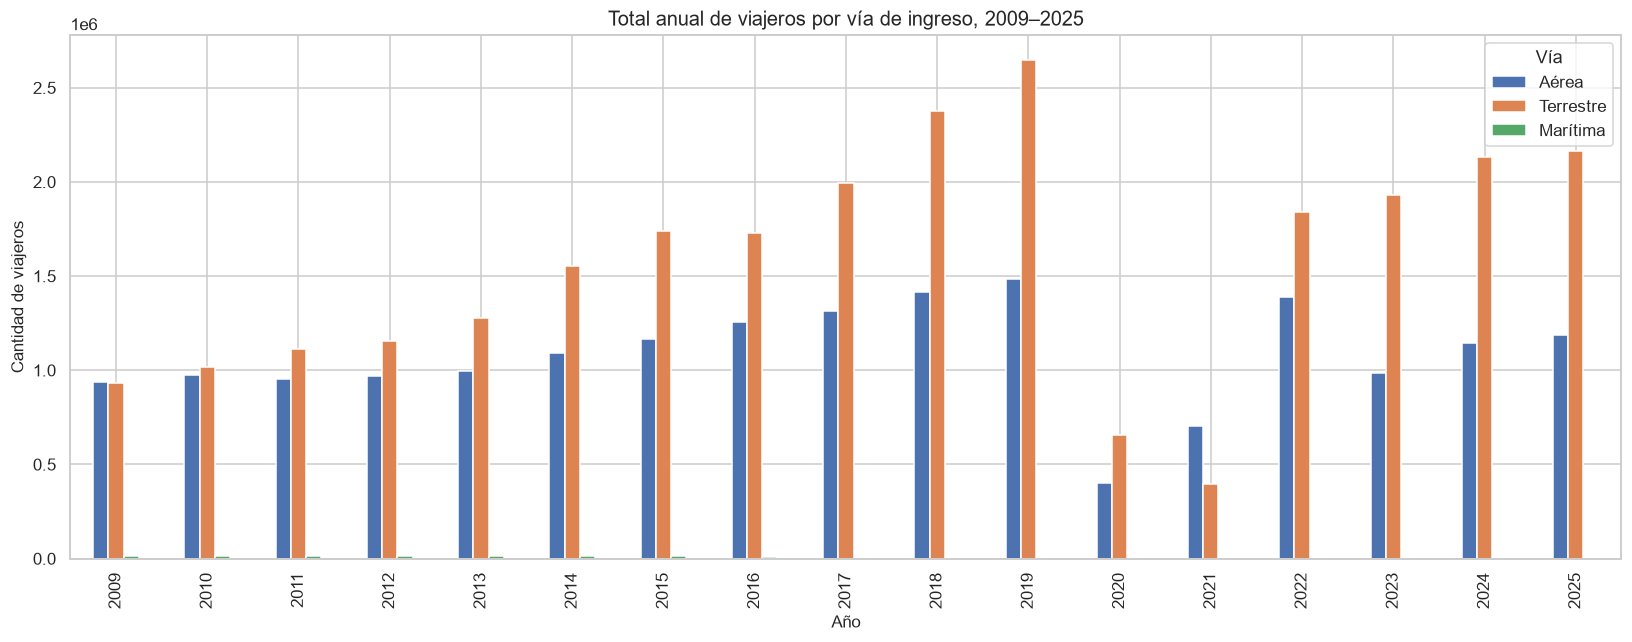

Total parcial enero-junio de 2026:


Vía,Aérea,Terrestre,Marítima
Fecha,,,
2026,"643,840.00","932,779.48",0.00


In [28]:
totales_anuales = (
    series_vias
    .resample("YS")
    .sum()
)

totales_anuales.index = totales_anuales.index.year

display(totales_anuales)

totales_anuales_completos = totales_anuales[
    totales_anuales.index <= 2025
]

ax = totales_anuales_completos.plot(
    kind="bar",
    figsize=(15, 6)
)

ax.set_title(
    "Total anual de viajeros por vía de ingreso, 2009–2025"
)

ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de viajeros")
ax.legend(title="Vía")

plt.tight_layout()
plt.show()

print("Total parcial enero-junio de 2026:")

display(
    totales_anuales[
        totales_anuales.index == 2026
    ]
)

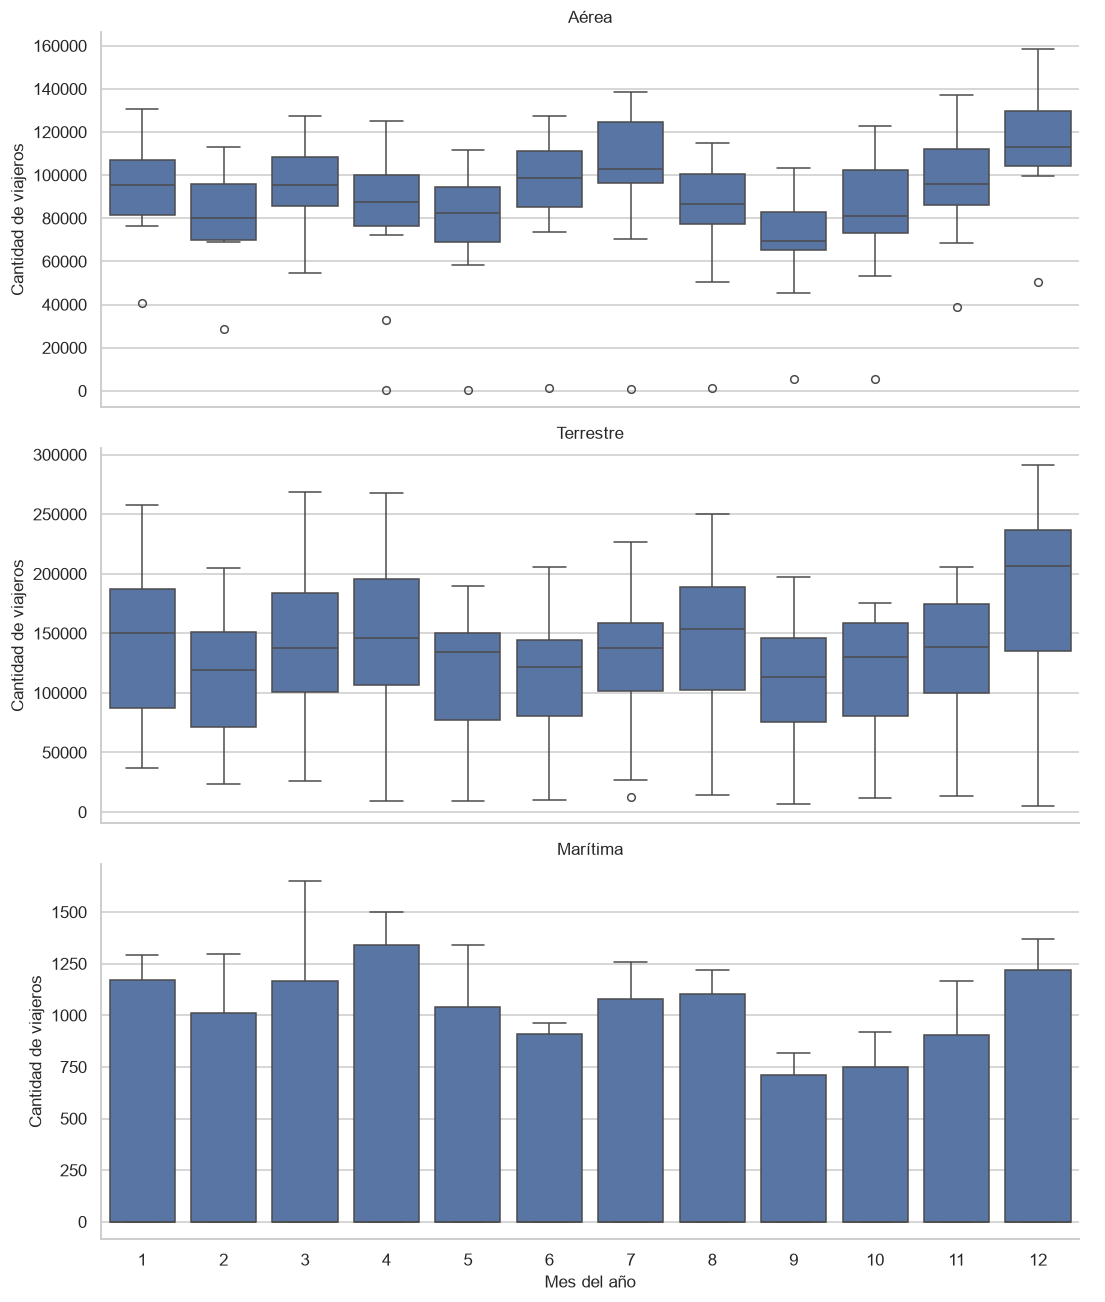

Vía,Aérea,Terrestre,Marítima
Fecha,,,
2019,"1,483,385.91","2,648,864.69",0.00
2020,"403,524.93","656,245.51",0.00
2021,"703,471.24","395,493.14",0.00
2022,"1,390,275.00","1,839,053.60",0.00
2023,"985,840.00","1,931,986.81",0.00


,Cambio_2020_vs_2019_porcentaje
Vía,
Aérea,-72.80
Terrestre,-75.23
Marítima,NaN


In [29]:
# ESTACIONARIEDAD MES Y AÑO 
series_largas = (
    series_vias
    .reset_index()
    .melt(
        id_vars="Fecha",
        var_name="Vía",
        value_name="Viajeros"
    )
)

series_largas["Mes_numero"] = (
    series_largas["Fecha"].dt.month
)

g = sns.catplot(
    data=series_largas,
    x="Mes_numero",
    y="Viajeros",
    col="Vía",
    kind="box",
    col_wrap=1,
    height=4,
    aspect=2.5,
    sharey=False
)

g.set_axis_labels(
    "Mes del año",
    "Cantidad de viajeros"
)

g.set_titles("{col_name}")

plt.show()

# ANALIAIS PANDEMIA 
comparacion_pandemia = totales_anuales.loc[
    totales_anuales.index.isin(
        [2019, 2020, 2021, 2022, 2023]
    )
].copy()

display(comparacion_pandemia)

caida_pandemia = (
    (
        totales_anuales.loc[2020]
        - totales_anuales.loc[2019]
    )
    / totales_anuales.loc[2019]
    * 100
)

caida_pandemia = (
    caida_pandemia
    .to_frame("Cambio_2020_vs_2019_porcentaje")
)

display(caida_pandemia)

### análisis de datos
Se nota una tendencia creciente en la vía aérea y terrestre, mientras que la vía marítima se mantiene estable. Sin embargo en la seccion de los años 2020 y 2021 se nota una disminución en las tres vías de ingreso, lo que puede estar relacionado con la pandemia de COVID-19. podemos ver la cantidad de cambio entre esas fechas y entre todas las vías de ingreso, lo que nos ayuda a entender el impacto de la pandemia en el tráfico de personas. 

## División de los datos en entrenamiento y prueba

Total de meses: 210
Meses de entrenamiento: 147
Meses de prueba: 63


,Conjunto,Inicio,Fin,Meses
0,Entrenamiento,2009-01-01,2021-03-01,147
1,Prueba,2021-04-01,2026-06-01,63


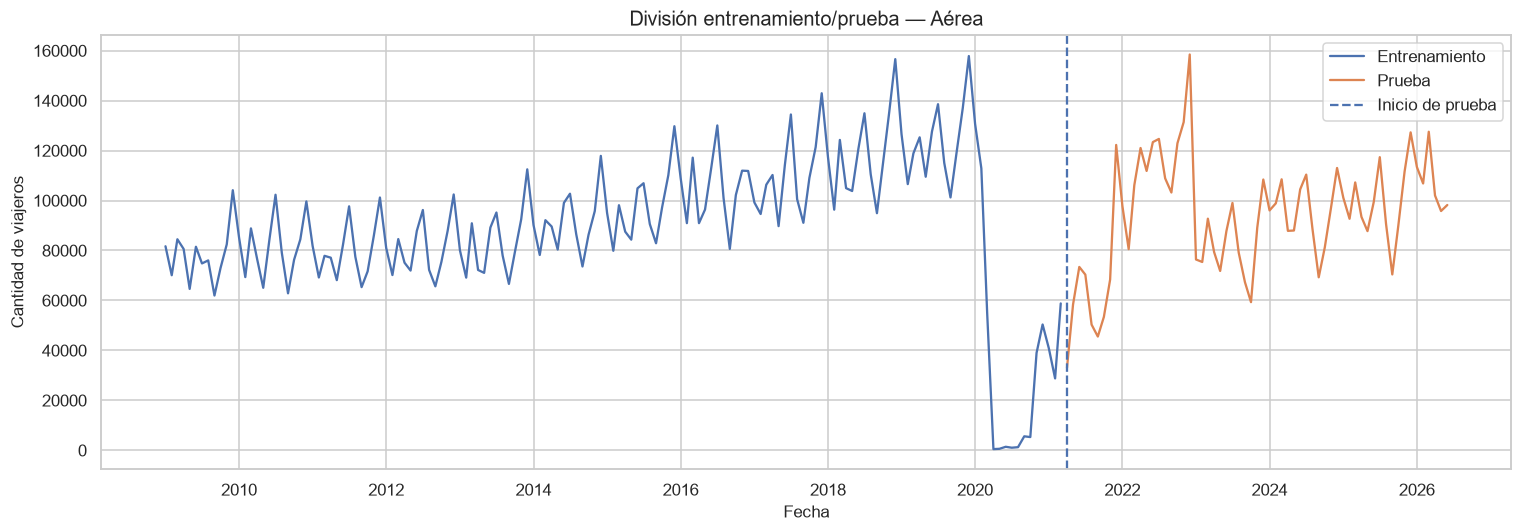

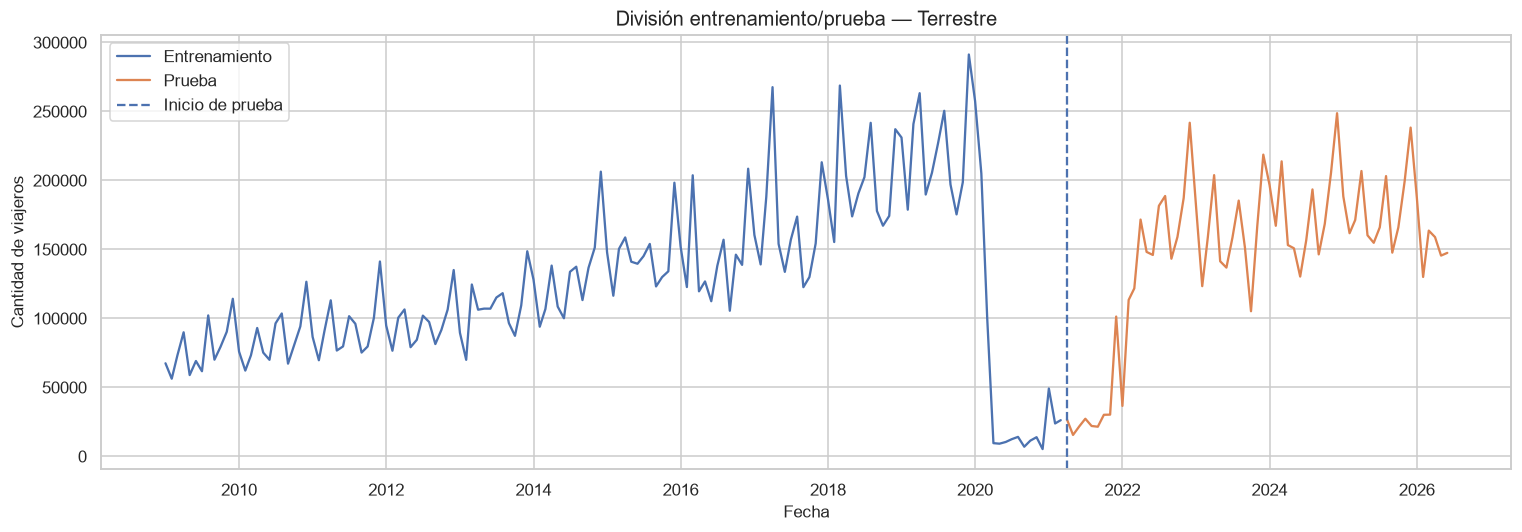

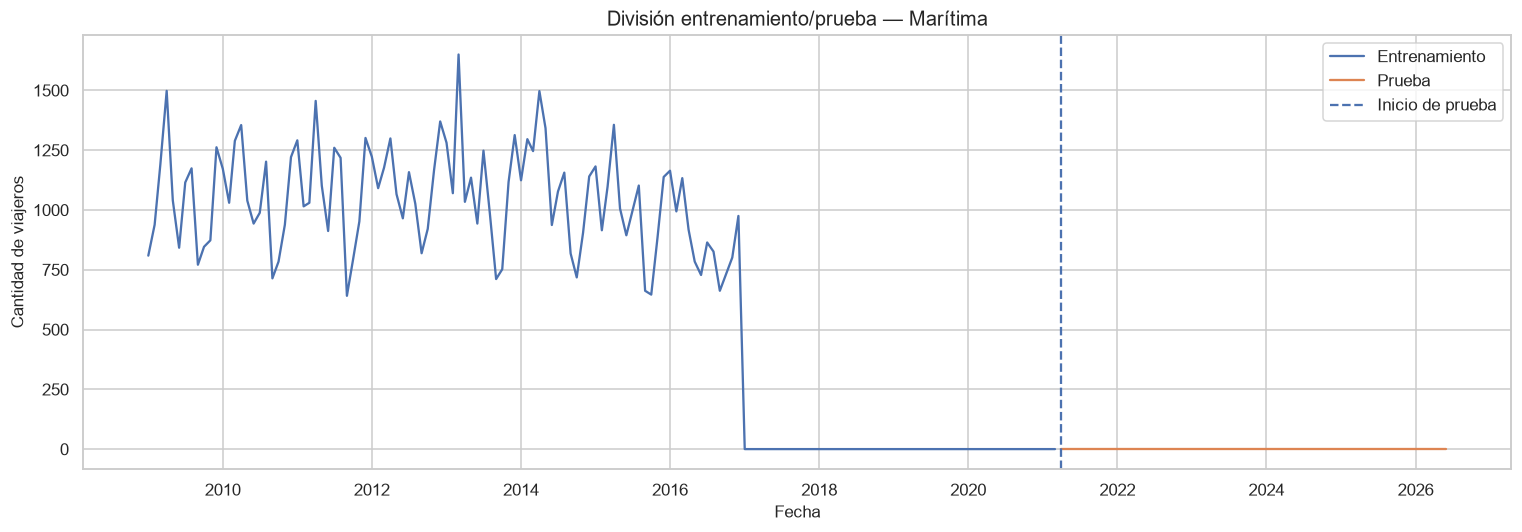

In [30]:
# divide 
cantidad_total = len(series_vias)

cantidad_train = int(
    np.floor(cantidad_total * 0.70)
)

cantidad_test = cantidad_total - cantidad_train

print("Total de meses:", cantidad_total)
print("Meses de entrenamiento:", cantidad_train)
print("Meses de prueba:", cantidad_test)

train_vias = (
    series_vias
    .iloc[:cantidad_train]
    .copy()
)

test_vias = (
    series_vias
    .iloc[cantidad_train:]
    .copy()
)

resumen_division = pd.DataFrame({
    "Conjunto": [
        "Entrenamiento",
        "Prueba"
    ],
    "Inicio": [
        train_vias.index.min(),
        test_vias.index.min()
    ],
    "Fin": [
        train_vias.index.max(),
        test_vias.index.max()
    ],
    "Meses": [
        len(train_vias),
        len(test_vias)
    ]
})

display(resumen_division)

for via in VIAS:
    plt.figure(figsize=(14, 5))

    plt.plot(
        train_vias.index,
        train_vias[via],
        label="Entrenamiento"
    )

    plt.plot(
        test_vias.index,
        test_vias[via],
        label="Prueba"
    )

    plt.axvline(
        test_vias.index.min(),
        linestyle="--",
        label="Inicio de prueba"
    )

    plt.title(
        f"División entrenamiento/prueba — {via}"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Cantidad de viajeros")
    plt.legend()

    plt.tight_layout()
    plt.show()

---

In [31]:
vias_despues_2016 = (
    datos.loc[
        datos["Fecha"] >= "2017-01-01",
        "Vía"
    ]
    .value_counts(dropna=False)
)

display(vias_despues_2016)

Vía
Terrestre    58102
Aérea        10303
Marítima      2008
Name: count, dtype: Int64

In [32]:
# ============================================================
# DIAGNÓSTICO DE LA VÍA MARÍTIMA
# ============================================================

# 1. Revisar todas las categorías de vía después de 2016
print("Vías registradas desde 2017:")
display(
    datos.loc[
        datos["Fecha"] >= "2017-01-01",
        "Vía"
    ].value_counts(dropna=False)
)


# 2. Buscar cualquier nombre relacionado con la vía marítima
print("\nNombres de vía relacionados con 'mar':")

vias_relacionadas_mar = [
    valor
    for valor in datos["Vía"].dropna().astype(str).unique()
    if "mar" in valor.lower()
]

for valor in vias_relacionadas_mar:
    print(repr(valor))


# 3. Tomar todos los registros marítimos, sin filtrar tipo de viajero
maritima_todos = datos[
    datos["Vía"]
    .astype("string")
    .str.contains(
        "mar",
        case=False,
        na=False
    )
].copy()

maritima_todos["Año_revision"] = (
    maritima_todos["Fecha"].dt.year
)


# 4. Resumen anual de todos los tipos de viajero
resumen_todos = (
    maritima_todos
    .groupby("Año_revision")
    .agg(
        Filas_todos=("Viajero", "size"),
        Total_todos=("Viajero", "sum")
    )
)


# 5. Resumen anual usando únicamente Turista y Excursionista
maritima_comparable = maritima_todos[
    maritima_todos["Tipo de Viajero"].isin(
        ["Turista", "Excursionista"]
    )
].copy()

resumen_comparable = (
    maritima_comparable
    .groupby("Año_revision")
    .agg(
        Filas_comparables=("Viajero", "size"),
        Total_comparable=("Viajero", "sum")
    )
)


# 6. Comparar ambas bases
comparacion_maritima = pd.concat(
    [
        resumen_todos,
        resumen_comparable
    ],
    axis=1
)

display(comparacion_maritima)


# 7. Revisar tipos de viajero marítimos
print("\nMarítima por tipo de viajero:")

display(
    maritima_todos
    .groupby("Tipo de Viajero")
    .agg(
        Filas=("Viajero", "size"),
        Total=("Viajero", "sum"),
        Primera_fecha=("Fecha", "min"),
        Última_fecha=("Fecha", "max")
    )
    .sort_values(
        "Total",
        ascending=False
    )
)


# 8. Construir la serie marítima SIN rellenar faltantes
serie_maritima_sin_rellenar = (
    maritima_comparable
    .groupby("Fecha")["Viajero"]
    .sum()
    .sort_index()
)

calendario_maritimo = pd.date_range(
    start=datos["Fecha"].min(),
    end=datos["Fecha"].max(),
    freq="MS"
)

serie_maritima_sin_rellenar = (
    serie_maritima_sin_rellenar
    .reindex(calendario_maritimo)
)

serie_maritima_sin_rellenar.index.name = "Fecha"


# 9. Diferenciar faltantes de ceros reales
print("\nDiagnóstico mensual:")

print(
    "Último mes con información:",
    serie_maritima_sin_rellenar.last_valid_index()
)

print(
    "Meses faltantes:",
    serie_maritima_sin_rellenar.isna().sum()
)

print(
    "Ceros registrados:",
    (serie_maritima_sin_rellenar == 0).sum()
)


# 10. Examinar el período donde ocurre el cambio
display(
    serie_maritima_sin_rellenar.loc[
        "2015-01-01":"2018-12-01"
    ].to_frame("Marítima")
)

Vías registradas desde 2017:


Vía
Terrestre    58102
Aérea        10303
Marítima      2008
Name: count, dtype: Int64


Nombres de vía relacionados con 'mar':
'Marítima'


,Filas_todos,Total_todos,Filas_comparables,Total_comparable
Año_revision,,,,
2009,973,"93,704.00",957.00,"12,358.00"
2010,980,"85,163.00",964.00,"12,675.00"
2011,981,"85,319.00",963.00,"12,969.00"
2012,1013,"86,128.00",997.00,"13,282.00"
2013,1058,"84,932.00","1,041.00","13,242.00"
2014,1067,"83,857.00","1,052.00","13,256.00"
2015,1055,"89,076.00","1,039.00","11,881.00"
2016,1029,"114,290.00","1,010.00","10,578.00"
2017,18,"129,063.00",NaN,NaN



Marítima por tipo de viajero:


,Filas,Total,Primera_fecha,Última_fecha
Tipo de Viajero,,,,
Cruceristas,204,"1,104,402.00",2009-01-01,2022-12-01
Turista,8023,"100,241.00",2009-01-01,2016-12-01
Viajero,1937,"24,139.00",2023-01-01,2026-06-01



Diagnóstico mensual:
Último mes con información: 2016-12-01 00:00:00
Meses faltantes: 114
Ceros registrados: 0


,Marítima
Fecha,
2015-01-01,"1,182.00"
2015-02-01,915.00
2015-03-01,"1,097.00"
2015-04-01,"1,356.00"
2015-05-01,"1,006.00"
2015-06-01,894.00
2015-07-01,996.00
2015-08-01,"1,102.00"
2015-09-01,662.00


# Análisis de la Serie Aérea 

## Información general de la serie

## Gráfico y Componentes 

## Estacionariedad en varianza

## Estacionariedad en media

## Selección de p, d y q 

## Modelos ARIMA 

## Modelos alternativos 

## Predicción y evaluación de los modelos

## Conclusiones 

---

# Análisis de la Serie Terrestre

# Análisis de la Serie Marítima 

# Comparación de tres vías 

# Descubrimientos y conclusiones